In [1]:
import pandas as pd

def replace_rare(dataframe, column, num_values=10):
    tmp = dataframe[column].value_counts()
    top_vals = tmp[0:num_values].index.to_list()
    dataframe.loc[~dataframe[column].isin(top_vals),column] = "OTHER"
    return 0

def data_prep():
    """
    Reads in a hard coded data frame and does cleanup. 
    First it selects only customers that have booked a destination.
    All dates are converted to timestamps
    3 columns have rare data, so I created an "other" category for each
    All Categorical variables are then OHE with get_dummies()
    Target Variauble is encoded.
    Final numeric data frame and map of class to country are returned.
    """
    train_data = pd.read_csv("./data/train_users.csv")
    first_booked = train_data.loc[~train_data['date_first_booking'].isna(),]
    first_booked['timestamp_first_active'] = pd.to_datetime(first_booked['timestamp_first_active'],format="%Y%m%d%H%M%S").astype('int64')
    first_booked['date_account_created']=pd.to_datetime(first_booked['date_account_created'], format="%Y-%m-%d").astype('int64')
    first_booked['date_first_booking'] = pd.to_datetime(first_booked['date_first_booking'], format="%Y-%m-%d").astype('int64')
    rare_data_cols = ['first_device_type','affiliate_provider','language','first_browser']
    encoded = first_booked.columns.to_list()
    for col in rare_data_cols:
        replace_rare(first_booked,col)
    indexes = [4,6,8,9,10,11,12,13,14]
    encoded = [encoded[i] for i in indexes]
    data = pd.get_dummies(first_booked,columns=encoded)
    country_data = pd.factorize(data['country_destination'])
    data ['country_destination'] = country_data[0]
    return data, country_data[1]

In [3]:
data, target_map = data_prep()

In [4]:
data

,id,date_account_created,timestamp_first_active,date_first_booking,age,signup_flow,country_destination,gender_-unknown-,gender_FEMALE,gender_MALE,...,first_browser_AOL Explorer,first_browser_Android Browser,first_browser_Chrome,first_browser_Chrome Mobile,first_browser_Firefox,first_browser_IE,first_browser_Mobile Safari,first_browser_OTHER,first_browser_Opera,first_browser_Safari
2,4ft3gnwmtx,1285632000000000,1244589167000000,1280707200000000,56.0,3,0,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,bjjt8pjhuk,1323043200000000,1256968889000000,1347062400000000,42.0,0,1,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,87mebub9p4,1284422400000000,1260252665000000,1266451200000000,41.0,0,0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
5,osr2jwljor,1262304000000000,1262382979000000,1262390400000000,NaN,0,0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
6,lsw9q7uk0j,1262390400000000,1262395558000000,1262649600000000,46.0,0,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,7plqriggxp,1404086400000000,1404169296000000,1404086400000000,55.0,0,2,True,False,False,...,False,False,False,False,False,True,False,False,False,False
213439,msucfwmlzc,1404086400000000,1404172049000000,1426464000000000,43.0,0,0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
213441,omlc9iku7t,1404086400000000,1404172311000000,1407888000000000,34.0,0,5,False,True,False,...,False,False,True,False,False,False,False,False,False,False
213443,0k26r3mir0,1404086400000000,1404172420000000,1405209600000000,36.0,0,0,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [21]:
from sklearn.ensemble import RandomForestClassifier #easy first method
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
rf_model = RandomForestClassifier(class_weight='balanced')

In [22]:
x = data.drop(['id','country_destination'], axis =1)
y = data['country_destination']

In [23]:
splits = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)
preds = cross_val_predict(rf_model, x, y, cv = splits, n_jobs=-1)

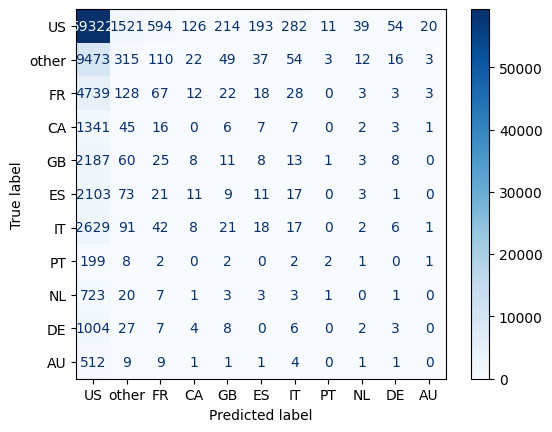

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
#well thats a bust!
ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=target_map.to_list(),cmap='Blues')

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y, preds))

              precision    recall  f1-score   support

           0       0.70      0.95      0.81     62376
           1       0.14      0.03      0.05     10094
           2       0.07      0.01      0.02      5023
           3       0.00      0.00      0.00      1428
           4       0.03      0.00      0.01      2324
           5       0.04      0.00      0.01      2249
           6       0.04      0.01      0.01      2835
           7       0.11      0.01      0.02       217
           8       0.00      0.00      0.00       762
           9       0.03      0.00      0.01      1061
          10       0.00      0.00      0.00       539

    accuracy                           0.67     88908
   macro avg       0.11      0.09      0.08     88908
weighted avg       0.52      0.67      0.58     88908



In [30]:
rf_model.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

<BarContainer object of 73 artists>

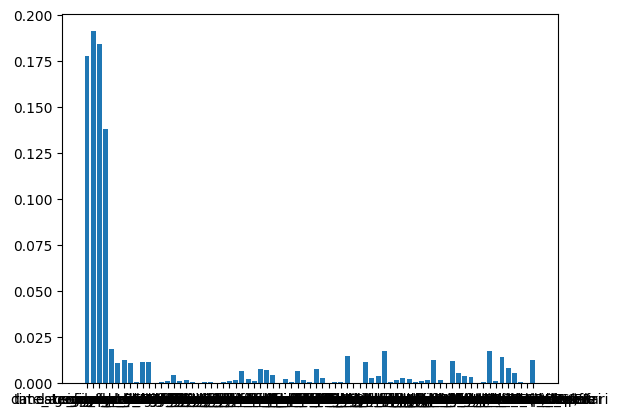

In [33]:
import matplotlib.pyplot as plt
plt.bar(x.columns.to_list(),rf_model.feature_importances_)
#yes this is a junky plot.  Its for my purposes only.
#does look like those timestamps are very important...look at some feature creation
# also may want to switch to a top-k classifier (I know how to do that in NN, but not XGB,RF

In [38]:
from sklearn.model_selection import RandomizedSearchCV
params = {"max_depth": [5,10,15,None], 
          "min_samples_split": [4,6,8,10], 
          "min_samples_leaf": [1,2,4], 
          "max_features":[5,10,15,'sqrt',20]
        }
search = RandomizedSearchCV(rf_model,param_distributions=params, scoring='balanced_accuracy', cv = splits, n_iter=20, n_jobs=-1)

In [39]:
results = search.fit(x,y)

In [40]:
results.best_score_

np.float64(0.12886469184206145)

In [41]:
results.sc

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [4, 6, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [42]:
results.cv_results_
#results did not vary much.  

{'mean_fit_time': array([ 6.6473361 ,  9.0559967 ,  8.95294681,  6.11175184, 29.81538172,
        29.0895802 ,  7.86548409,  8.83752193, 21.06304026, 40.74989548,
        23.23058782,  5.75696249, 13.22492061,  6.41529436, 10.28871937,
        26.44039307, 11.89103427,  9.22458959, 12.8997067 ,  8.75790448]),
 'std_fit_time': array([0.39849514, 0.54591608, 0.39870402, 0.18743098, 0.38052965,
        0.37011882, 1.07417902, 1.33696176, 0.36375981, 1.09336627,
        0.51768748, 0.98426716, 0.43524163, 0.23013034, 0.28792481,
        0.27545586, 0.35324894, 1.42635198, 0.26646178, 1.553832  ]),
 'mean_score_time': array([0.23116145, 0.46486621, 0.47537475, 0.21807499, 0.48951125,
        0.52583213, 0.19614372, 0.38774109, 0.4488976 , 0.80786757,
        0.51713548, 0.18820662, 0.41971292, 0.20272713, 0.4773416 ,
        0.68719425, 0.82772341, 0.4131701 , 0.38788552, 0.1454422 ]),
 'std_score_time': array([0.01270787, 0.04238196, 0.01827196, 0.01242839, 0.04221366,
        0.02252012, 

In [43]:
results.best_params_

{'min_samples_split': 4,
 'min_samples_leaf': 4,
 'max_features': 10,
 'max_depth': 10}

In [60]:
from sklearn.metrics import top_k_accuracy_score
rf_model_best = RandomForestClassifier(min_samples_leaf=4,min_samples_split=4, max_features=10, max_depth=10, n_jobs = -1, class_weight='balanced')
probs = cross_val_predict(rf_model_best, x, y, method = 'predict_proba', cv = splits)
preds = cross_val_predict(rf_model_best, x, y, cv = splits)

In [61]:
top_k_accuracy_score(y,probs,k=3)
#ok i might be able to deal with that....or its weighted by the US destinations

0.4250461150852567

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y, preds)

0.12672650380168263

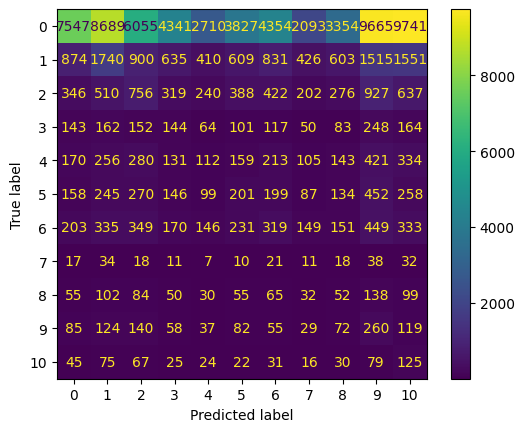

In [65]:
ConfusionMatrixDisplay.from_predictions(y, preds)

In [64]:

print(classification_report(y, preds))

              precision    recall  f1-score   support

           0       0.78      0.12      0.21     62376
           1       0.14      0.17      0.16     10094
           2       0.08      0.15      0.11      5023
           3       0.02      0.10      0.04      1428
           4       0.03      0.05      0.04      2324
           5       0.04      0.09      0.05      2249
           6       0.05      0.11      0.07      2835
           7       0.00      0.05      0.01       217
           8       0.01      0.07      0.02       762
           9       0.02      0.25      0.03      1061
          10       0.01      0.23      0.02       539

    accuracy                           0.13     88908
   macro avg       0.11      0.13      0.07     88908
weighted avg       0.57      0.13      0.18     88908



In [66]:
x

,date_account_created,timestamp_first_active,date_first_booking,age,signup_flow,gender_-unknown-,gender_FEMALE,gender_MALE,gender_OTHER,signup_method_basic,...,first_browser_AOL Explorer,first_browser_Android Browser,first_browser_Chrome,first_browser_Chrome Mobile,first_browser_Firefox,first_browser_IE,first_browser_Mobile Safari,first_browser_OTHER,first_browser_Opera,first_browser_Safari
2,1285632000000000,1244589167000000,1280707200000000,56.0,3,False,True,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,1323043200000000,1256968889000000,1347062400000000,42.0,0,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1284422400000000,1260252665000000,1266451200000000,41.0,0,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
5,1262304000000000,1262382979000000,1262390400000000,NaN,0,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
6,1262390400000000,1262395558000000,1262649600000000,46.0,0,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213415,1404086400000000,1404169296000000,1404086400000000,55.0,0,True,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
213439,1404086400000000,1404172049000000,1426464000000000,43.0,0,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
213441,1404086400000000,1404172311000000,1407888000000000,34.0,0,False,True,False,False,True,...,False,False,True,False,False,False,False,False,False,False
213443,1404086400000000,1404172420000000,1405209600000000,36.0,0,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [67]:
import xgboost as xgb


In [81]:
dtrain = xgb.DMatrix(x, label=y, weight=sample_weights)
param = {"max_depth": 10, "eta": 0.03, "objective": "multi:softmax", "num_class":11, 'eval_metric': ['merror','mlogloss']}
out = xgb.cv(params=param, dtrain=dtrain, num_boost_round = 200, nfold=5, verbose_eval=True, early_stopping_rounds=20)

[0]	train-merror:0.73697+0.06660	train-mlogloss:2.37925+0.00125	test-merror:0.90655+0.02244	test-mlogloss:2.39853+0.00238
[1]	train-merror:0.70178+0.04564	train-mlogloss:2.36211+0.00235	test-merror:0.89965+0.02160	test-mlogloss:2.39749+0.00239
[2]	train-merror:0.68032+0.04050	train-mlogloss:2.34560+0.00379	test-merror:0.89742+0.02045	test-mlogloss:2.39656+0.00226
[3]	train-merror:0.66810+0.03614	train-mlogloss:2.32959+0.00496	test-merror:0.89654+0.01860	test-mlogloss:2.39580+0.00224
[4]	train-merror:0.65917+0.03094	train-mlogloss:2.31435+0.00611	test-merror:0.89513+0.01848	test-mlogloss:2.39522+0.00224
[5]	train-merror:0.64867+0.02953	train-mlogloss:2.29956+0.00741	test-merror:0.89371+0.01474	test-mlogloss:2.39478+0.00224
[6]	train-merror:0.63869+0.02505	train-mlogloss:2.28528+0.00847	test-merror:0.89143+0.01305	test-mlogloss:2.39428+0.00234
[7]	train-merror:0.63205+0.02482	train-mlogloss:2.27195+0.00952	test-merror:0.89117+0.01117	test-mlogloss:2.39406+0.00230
[8]	train-merror:0.62597

In [79]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Compute a weight array matching the length of y_train
# 'balanced' calculates weights inversely proportional to class frequencies
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

In [80]:
sample_weights

array([0.12957781, 0.80072771, 0.12957781, ..., 3.59383969, 0.12957781,
       0.12957781], shape=(88908,))

In [84]:
#Running a little short on time  Start with the RF model  Train it for deployment
rf_model_best = RandomForestClassifier(min_samples_leaf=4,min_samples_split=4, max_features=10, max_depth=10, n_jobs = -1, class_weight='balanced')
rf_model_best.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [90]:
import skops.io as sio
sio.dump(rf_model_best, "model.skops")

In [92]:
sio.get_untrusted_types(file="./model.skops")

[]

In [91]:
help(sio.get_untrusted_types)

Help on function get_untrusted_types in module skops.io._persist:

get_untrusted_types(*, data: 'bytes | None' = None, file: 'str | Path | None' = None) -> 'list[str]'
    Get a list of untrusted types in a skops dump.

    Parameters
    ----------
    data: bytes
        The data to be checked, in bytes format.

    file: str or Path
        The file to be checked.

    Returns
    -------
    untrusted_types: list of str
        The list of untrusted types in the dump.

    Notes
    -----
    Only one of data or file should be passed.



In [111]:
user_data = data[data['id']=='4ft3gnwmtx']
out = rf_model_best.predict(sample.drop(['id','country_destination'],axis=1))

In [120]:
out.item()

2

In [100]:
x.shape

(88908, 73)

In [101]:
x.columns

Index(['date_account_created', 'timestamp_first_active', 'date_first_booking',
       'age', 'signup_flow', 'gender_-unknown-', 'gender_FEMALE',
       'gender_MALE', 'gender_OTHER', 'signup_method_basic',
       'signup_method_facebook', 'signup_method_google', 'language_OTHER',
       'language_de', 'language_en', 'language_es', 'language_fr',
       'language_it', 'language_ja', 'language_ko', 'language_pt',
       'language_ru', 'language_zh', 'affiliate_channel_api',
       'affiliate_channel_content', 'affiliate_channel_direct',
       'affiliate_channel_other', 'affiliate_channel_remarketing',
       'affiliate_channel_sem-brand', 'affiliate_channel_sem-non-brand',
       'affiliate_channel_seo', 'affiliate_provider_OTHER',
       'affiliate_provider_bing', 'affiliate_provider_craigslist',
       'affiliate_provider_direct', 'affiliate_provider_facebook',
       'affiliate_provider_facebook-open-graph', 'affiliate_provider_google',
       'affiliate_provider_other', 'affiliate_p

In [122]:
target_map[2]

'FR'